# Popularidade x qualidade

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid")


In [ ]:
movies = pd.read_parquet('db/movies.parquet')

ratings = pd.read_parquet('db/ratings.parquet')


movies = movies.merge(
    ratings,
    on='tconst',
    how='inner'
)

movies = movies.dropna(
   subset=['primaryTitle', 'startYear', 'averageRating', 'numVotes']
)
# Combinar tabelas separadas para poder realizar a análise
movies.head()

In [ ]:
patterns = [
    r"(?:\s|:)(2|3|4|5|6|7|8|9)\b",
    r"\bpart\b",
    r"\bchapter\b",
    r"\breturns\b",
    r"\bii\b",
    r"\biii\b",
    r"\biv\b",
    r"\bv\b",
    r"\bvi\b",
    r"\bvs\b",
    r"\borigins\b",
    r"\blegacy\b",
    r"\breloaded\b",
    r"\brevolutions\b",
    r"\bfinal\b"
]

regex = re.compile("|".join(patterns), re.IGNORECASE)

movies['franquia'] = movies['primaryTitle'].apply(
    lambda x: bool(regex.search(str(x)))
)



franquia
False    334580
True       8847
Name: count, dtype: int64

In [37]:
originais = movies[movies['franquia'] == False].copy()
franquias = movies[movies['franquia'] == True].copy()

# Popularidade
Calculada por `numVotes`


In [ ]:
# Problema: Como fazer para visualizar se podem ter filmes com 10 votos e filmes com 1000000 votos?
# Solução: Usar uma transformação nos dados para melhorar a visualização. No caso Log10 para "normalizar as grandezas".
movies['logVotes'] = np.log10(movies['numVotes'] + 1)
originais['logVotes'] = np.log10(originais['numVotes'] + 1)
franquias['logVotes'] = np.log10(franquias['numVotes'] + 1)


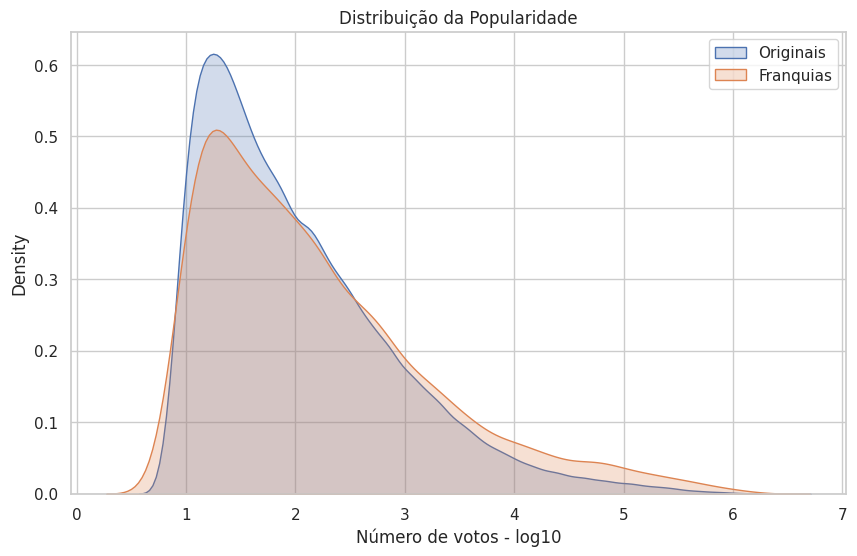

In [ ]:
plt.figure(figsize=(10,6))

sns.kdeplot(originais['logVotes'],
            label='Originais',
            fill=True)

sns.kdeplot(franquias['logVotes'],
            label='Franquias',
            fill=True)

plt.xlabel('Número de votos - log10')
plt.ylabel('Porcentagem da amostra')
plt.title('Distribuição da Popularidade')
plt.legend()
plt.show()


# Qualidade

Calculada por `averageRating`.


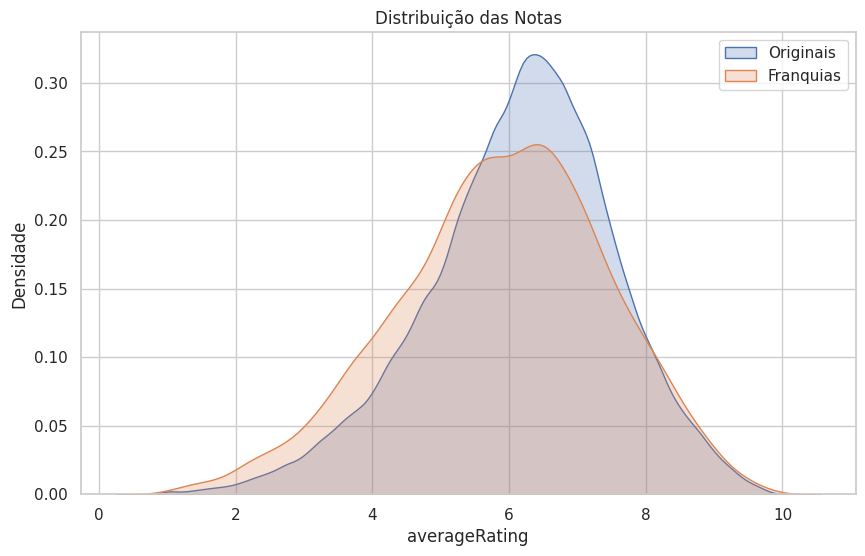

In [36]:
plt.figure(figsize=(10,6))

sns.kdeplot(originais['averageRating'],
            label='Originais',
            fill=True)

sns.kdeplot(franquias['averageRating'],
            label='Franquias',
            fill=True)

plt.xlabel('averageRating')
plt.ylabel('Densidade')
plt.title('Distribuição das Notas')
plt.legend()
plt.show()
